# A newral network training from scratch for the XOR function


A small neural network example implemented completely manually and then for comparison with Keras/TensorFlow.

## XOR Neural Network

A simple feed-forward network:
- 2 input neurons
- 2 hidden neurons
- 1 output neuron

Demonstrates:
- forward propagation
- backpropagation
- binary classification


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # transposed, so 2x4 matrix, each column is a training example
d = np.array([0, 1, 1, 0])  # Expected output for XOR

In [3]:
def initialize_network_parameters():
    # Network parameters
    inputSize = 2      # Number of input neurons (x1, x2)
    hiddenSize = 2     # Number of hidden neurons
    outputSize = 1     # Number of output neurons
    lr = 0.1           # Learning rate
    epochs = 180_000    # Number of training epochs

    # Initialize weights and biases randomly within the range [-1, 1]
    w1 = np.random.rand(hiddenSize, inputSize) * 2 - 1  # Weights from input to hidden layer
    b1 = np.random.rand(hiddenSize, 1) * 2 - 1          # Bias for hidden layer
    w2 = np.random.rand(outputSize, hiddenSize) * 2 - 1 # Weights from hidden to output layer
    b2 = np.random.rand(outputSize, 1) * 2 - 1          # Bias for output layer

    return w1, b1, w2, b2, lr, epochs

## The Neural Network Training Process

The neural network training works in stages:

1. **Forward pass**
2. **Error calculation**
3. **Backpropagation updates weights and bias**
4. **Repeat from step 1**
   - The entire process is repeated over many iterations (**epochs**).
   - During each epoch, the model adjusts its weights and biases to reduce the error.
   - Over time, the network learns to approximate the XOR function.

## Derivative of the Sigmoid Function

The **sigmoid function** is defined as

$$
\sigma(x) = \frac{1}{1 + e^{-x}}.
$$

Its derivative has a particularly elegant form:

$$
\boxed{\sigma'(x) = \sigma(x)\left(1 - \sigma(x)\right)}.
$$

This identity is widely used in machine learning because it allows the derivative to be computed directly from the sigmoid's output.

### Derivation

Start with the sigmoid function:

$$
\sigma(x) = (1 + e^{-x})^{-1}.
$$

Differentiate using the **chain rule**:

$$
\begin{aligned}
\sigma'(x)
&= \frac{d}{dx}(1 + e^{-x})^{-1} \\
&= -(1 + e^{-x})^{-2} \cdot \frac{d}{dx}(1 + e^{-x}) \\
&= -(1 + e^{-x})^{-2} \cdot (-e^{-x}) \\
&= \frac{e^{-x}}{(1 + e^{-x})^2}.
\end{aligned}
$$

Now rewrite this expression in terms of the sigmoid itself:

$$
\begin{aligned}
\frac{e^{-x}}{(1 + e^{-x})^2}
&=
\frac{1}{1 + e^{-x}}
\left(1 - \frac{1}{1 + e^{-x}}\right) \\
&=
\sigma(x)\left(1 - \sigma(x)\right).
\end{aligned}
$$

In [44]:
%%time 

# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = a2-d  # Derivative of the error function 1/2*(d-a2)**2 => 1/2*2*(d-a2)*(-1) 
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 -= lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 -= lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 -= lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 -= lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))

Epoch: 9999, Average error: 0.05665
Epoch: 19999, Average error: 0.03088
Epoch: 29999, Average error: 0.02341
Epoch: 39999, Average error: 0.01954
Epoch: 49999, Average error: 0.01709
Epoch: 59999, Average error: 0.01537
Epoch: 69999, Average error: 0.01407
Epoch: 79999, Average error: 0.01305
Epoch: 89999, Average error: 0.01222
Epoch: 99999, Average error: 0.01153
Epoch: 109999, Average error: 0.01094
Epoch: 119999, Average error: 0.01044
Epoch: 129999, Average error: 0.00999
Epoch: 139999, Average error: 0.00960
Epoch: 149999, Average error: 0.00925
Epoch: 159999, Average error: 0.00894
Epoch: 169999, Average error: 0.00865
Epoch: 179999, Average error: 0.00839
CPU times: total: 8.47 s
Wall time: 8.36 s


## Testing the trained network

In [5]:
# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('Final output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))

Final output after training: [[0.0094704  0.99195477 0.99196107 0.00823539]]
Ground truth [0 1 1 0]
Error after training: [[ 0.00947043 -0.00804526 -0.00803895  0.00823541]]
Average error: 0.00845


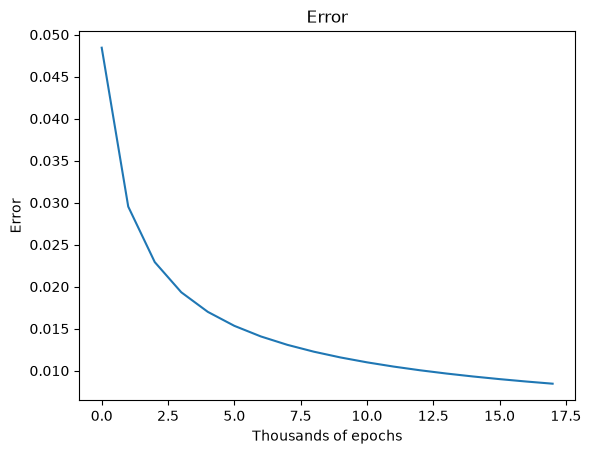

In [6]:
# Plot error during different epochs
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Thousands of epochs')
plt.ylabel('Error')
plt.show()

## You can stop now or follow the details of all derivatives in the backpropagation

# Backpropagation for a 2–2–1 Neural Network Solving XOR

Consider a neural network with:

- **2 input neurons**
- **2 hidden neurons**
- **1 output neuron**

Assume the hidden and output layers both use the **Sigmoid** activation function.


### Inputs

The input vector is

$$
X =
\begin{bmatrix}
x_1 & x_2
\end{bmatrix}.
$$

### Hidden Layer

The weighted sums entering the hidden neurons are

$$
z_1 = x_1w_{11}+x_2w_{21}+b_1
$$

$$
z_2 = x_1w_{12}+x_2w_{22}+b_2
$$

Applying the sigmoid activation gives

$$
a_1=\sigma(z_1)
$$

$$
a_2=\sigma(z_2)
$$

These activations become the inputs to the output neuron.

### Output Layer

The output neuron computes

$$
z_3=a_1v_1+a_2v_2+b_3
$$

and applies the sigmoid activation

$$
\hat y=\sigma(z_3)
$$

where

- $\hat y$ is the predicted output.
- $y$ is the expected output.

---

# Loss Function

Using the Mean Squared Error (MSE),

$$
L=\frac12(y-\hat y)^2
$$

The objective of backpropagation is to compute

$$
\frac{\partial L}{\partial w}
$$

for every weight and bias in the network.

---

# Step 1 — Error at the Output Neuron

We begin at the output because it is directly connected to the loss.

The chain rule tells us

$$
\frac{\partial L}{\partial z_3}
=
\frac{\partial L}{\partial \hat y}
\cdot
\frac{\partial \hat y}{\partial z_3}
$$

## First derivative

Differentiate the loss:

$$
L=\frac12(y-\hat y)^2
$$

Therefore,

$$
\frac{\partial L}{\partial \hat y}
=
-(y-\hat y)
=
\hat y-y
$$

## Second derivative

Since

$$
\hat y=\sigma(z_3),
$$

the sigmoid derivative is

$$
\frac{\partial\hat y}{\partial z_3}
=
\hat y(1-\hat y)
$$

Combining both,

$$
\boxed{
\delta_3
=
\frac{\partial L}{\partial z_3}
=
(\hat y-y)\hat y(1-\hat y)
}
$$

This quantity is often called the **output error**.

---

# Step 2 — Gradients for the Output Weights

The output neuron has two incoming weights:

- $v_1$
- $v_2$

Using the chain rule,

## Weight $v_1$

$$
\frac{\partial L}{\partial v_1}
=
\frac{\partial L}{\partial z_3}
\cdot
\frac{\partial z_3}{\partial v_1}
$$

Since

$$
z_3=a_1v_1+a_2v_2+b_3,
$$

we have

$$
\frac{\partial z_3}{\partial v_1}=a_1
$$

Thus,

$$
\boxed{
\frac{\partial L}{\partial v_1}
=
\delta_3a_1
}
$$

Similarly,

$$
\boxed{
\frac{\partial L}{\partial v_2}
=
\delta_3a_2
}
$$

---

# Step 3 — Gradient for the Output Bias

Because

$$
\frac{\partial z_3}{\partial b_3}=1,
$$

we obtain

$$
\boxed{
\frac{\partial L}{\partial b_3}
=
\delta_3
}
$$

---

# Step 4 — Propagating the Error to the Hidden Layer

The hidden neurons influence the loss only through the output neuron.

Again, apply the chain rule.

## Hidden neuron 1

$$
\frac{\partial L}{\partial z_1}
=
\frac{\partial L}{\partial z_3}
\cdot
\frac{\partial z_3}{\partial a_1}
\cdot
\frac{\partial a_1}{\partial z_1}
$$

We know

$$
\frac{\partial L}{\partial z_3}
=
\delta_3
$$

Since

$$
z_3=a_1v_1+a_2v_2+b_3,
$$

then

$$
\frac{\partial z_3}{\partial a_1}
=
v_1
$$

Finally,

$$
\frac{\partial a_1}{\partial z_1}
=
a_1(1-a_1)
$$

Therefore,

$$
\boxed{
\delta_1
=
\delta_3v_1a_1(1-a_1)
}
$$

---

For the second hidden neuron,

$$
\boxed{
\delta_2
=
\delta_3v_2a_2(1-a_2)
}
$$

---

# Step 5 — Gradients for the Hidden Weights

Consider weight $w_{11}$.

Using the chain rule,

$$
\frac{\partial L}{\partial w_{11}}
=
\frac{\partial L}{\partial z_1}
\cdot
\frac{\partial z_1}{\partial w_{11}}
$$

Since

$$
z_1=x_1w_{11}+x_2w_{21}+b_1,
$$

we obtain

$$
\frac{\partial z_1}{\partial w_{11}}
=
x_1
$$

Thus,

$$
\boxed{
\frac{\partial L}{\partial w_{11}}
=
\delta_1x_1
}
$$

Similarly,

$$
\boxed{
\frac{\partial L}{\partial w_{21}}
=
\delta_1x_2
}
$$

For the second hidden neuron,

$$
\boxed{
\frac{\partial L}{\partial w_{12}}
=
\delta_2x_1
}
$$

$$
\boxed{
\frac{\partial L}{\partial w_{22}}
=
\delta_2x_2
}
$$

---

# Step 6 — Gradients for the Hidden Biases

Since

$$
\frac{\partial z_1}{\partial b_1}=1,
$$

we have

$$
\boxed{
\frac{\partial L}{\partial b_1}
=
\delta_1
}
$$

Likewise,

$$
\boxed{
\frac{\partial L}{\partial b_2}
=
\delta_2
}
$$

---

# Step 7 — Update the Parameters

Once every gradient has been computed, each parameter is updated using gradient descent.

For every weight,

$$
w_{\text{new}}
=
w_{\text{old}}
-
\eta
\frac{\partial L}{\partial w}
$$

and for every bias,

$$
b_{\text{new}}
=
b_{\text{old}}
-
\eta
\frac{\partial L}{\partial b}
$$

where $\eta$ is the learning rate.

---

# Summary of All Gradients

## Output layer

$$
\delta_3=(\hat y-y)\hat y(1-\hat y)
$$

$$
\frac{\partial L}{\partial v_1}
=
\delta_3a_1
$$

$$
\frac{\partial L}{\partial v_2}
=
\delta_3a_2
$$

$$
\frac{\partial L}{\partial b_3}
=
\delta_3
$$

---

## Hidden layer

$$
\delta_1
=
\delta_3v_1a_1(1-a_1)
$$

$$
\delta_2
=
\delta_3v_2a_2(1-a_2)
$$

$$
\frac{\partial L}{\partial w_{11}}
=
\delta_1x_1
$$

$$
\frac{\partial L}{\partial w_{21}}
=
\delta_1x_2
$$

$$
\frac{\partial L}{\partial w_{12}}
=
\delta_2x_1
$$

$$
\frac{\partial L}{\partial w_{22}}
=
\delta_2x_2
$$

$$
\frac{\partial L}{\partial b_1}
=
\delta_1
$$

$$
\frac{\partial L}{\partial b_2}
=
\delta_2
$$

This sequence of chain-rule applications is the essence of **backpropagation**: starting from the loss, the error is propagated backward through the output layer to the hidden layer, allowing every weight and bias in the network to receive the gradient needed for gradient descent.

## Same thing with Keras

In [7]:
import keras

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

In [43]:
print(keras.__version__)

3.15.1


In [18]:
X_keras = X.T # Transpose for Keras - examples are rows
y_keras = d

In [46]:
model = Sequential([
    Input(shape=(2,)),
    Dense(2, activation="sigmoid"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="sgd", # try also others - for example "adam"
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [47]:
model.predict(X_keras)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([[0.5441393 ],
       [0.5665439 ],
       [0.4772828 ],
       [0.50141966]], dtype=float32)

In [48]:
%%time

history = model.fit(
    X_keras,
    y_keras,
    epochs=10_000,
    #batch_size=4,
    verbose=0
)

CPU times: total: 6min 47s
Wall time: 5min 17s


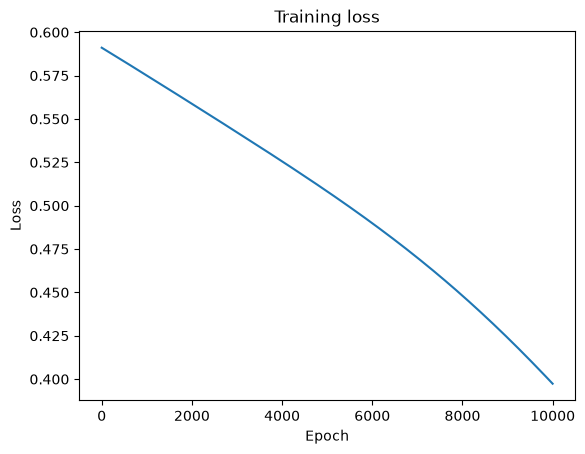

In [39]:
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

In [40]:
predictions = model.predict(X_keras)
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([[0.14118774],
       [0.71494186],
       [0.6853807 ],
       [0.5150839 ]], dtype=float32)

In [41]:
print('Average error: %0.05f'%np.average(abs(predictions - d)))

Average error: 0.50000


In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)